# TM Barrier Scenario 1 — Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

TARGET = 'TM_barrier_scenario_1'

## 1. Load & inspect data

In [ ]:
df = pd.read_csv(r"MKM-df-TM-barriers-INTIAL.csv")

# Short labels for boron species
boh2_map = {
    'BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole-4-boronic_acid': 'BOH2-cpd2',
    'BOH2Ar_compound_6_benzofuran-2-boronic_acid':                    'BOH2-cpd6',
    'BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boronic_acid':        'BOH2-cpd9',
}
bpin_map = {
    'BPinAr_compound_2_as_BPin_35-dimethylisoxazole-4-boronate': 'BPin-cpd2',
    'BPinAr_compound_6_benzofuran-2-boronate':                   'BPin-cpd6',
    'BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boronate':        'BPin-cpd9',
}
df['BOH2_short'] = df['boron species (BOH2)'].map(boh2_map)
df['BPin_short'] = df['boron species (BPin)'].map(bpin_map)

print(df.shape)
df.head(10)

(160, 10)


,temp_C,substrate,boron species (BOH2),boron species (BPin),ligand,case,TM_barrier_scenario_1,TM_barrier_scenario_2,BOH2_short,BPin_short
0,30,3_bromoquinoline,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PCy3,case1,11.376544,12.109558,BOH2-cpd2,BPin-cpd2
1,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PCy3,case2,12.110510,14.892455,BOH2-cpd2,BPin-cpd2
2,30,3_chloropyridine,BOH2Ar_compound_6_benzofuran-2-boronic_acid,BPinAr_compound_6_benzofuran-2-boronate,PCy3,case3,14.169073,12.105832,BOH2-cpd6,BPin-cpd6
3,30,2_chloropyridine,BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boro...,BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boro...,PCy3,case4,15.885117,12.217347,BOH2-cpd9,BPin-cpd9
4,30,3_bromoquinoline,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PPh3,case1,7.861396,10.244734,BOH2-cpd2,BPin-cpd2
5,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,PPh3,case2,9.322000,10.930178,BOH2-cpd2,BPin-cpd2
6,30,3_chloropyridine,BOH2Ar_compound_6_benzofuran-2-boronic_acid,BPinAr_compound_6_benzofuran-2-boronate,PPh3,case3,11.331644,10.082327,BOH2-cpd6,BPin-cpd6
7,30,2_chloropyridine,BOH2Ar_compound_9_as_BOH2_1-Boc-pyrrole-2-boro...,BPinAr_compound_9_as_BPin_1-Boc-pyrrole-2-boro...,PPh3,case4,8.663133,7.674602,BOH2-cpd9,BPin-cpd9
8,30,3_bromoquinoline,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,AmPhos,case1,8.829404,14.868009,BOH2-cpd2,BPin-cpd2
9,30,3_chloropyridine,BOH2Ar_compound_2_as_BOH2_35-dimethylisoxazole...,BPinAr_compound_2_as_BPin_35-dimethylisoxazole...,AmPhos,case2,9.287848,15.112879,BOH2-cpd2,BPin-cpd2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 160 non-null    int64  
 1   substrate              160 non-null    object 
 2   boron species (BOH2)   160 non-null    object 
 3   boron species (BPin)   160 non-null    object 
 4   ligand                 160 non-null    object 
 5   case                   160 non-null    object 
 6   TM_barrier_scenario_1  160 non-null    float64
 7   TM_barrier_scenario_2  160 non-null    float64
 8   BOH2_short             160 non-null    object 
 9   BPin_short             160 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 12.6+ KB


In [4]:
df[TARGET].describe().round(3)

count    160.000
mean      11.778
std        3.732
min        2.266
25%        9.112
50%       11.959
75%       13.657
max       20.093
Name: TM_barrier_scenario_1, dtype: float64

In [5]:
print('Temperatures (°C):', sorted(df['temp_C'].unique()))
print('Substrates:       ', df['substrate'].unique().tolist())
print('Ligands:          ', df['ligand'].unique().tolist())
print('BOH2 species:     ', df['BOH2_short'].unique().tolist())
print('BPin species:     ', df['BPin_short'].unique().tolist())
print('Cases:            ', sorted(df['case'].unique()))

Temperatures (°C): [np.int64(30), np.int64(50), np.int64(70), np.int64(90), np.int64(110)]
Substrates:        ['3_bromoquinoline', '3_chloropyridine', '2_chloropyridine']
Ligands:           ['PCy3', 'PPh3', 'AmPhos', 'Catacxium_A', 'RuPhos', 'SPhos', 'tBu3', 'XPhos']
BOH2 species:      ['BOH2-cpd2', 'BOH2-cpd6', 'BOH2-cpd9']
BPin species:      ['BPin-cpd2', 'BPin-cpd6', 'BPin-cpd9']
Cases:             ['case1', 'case2', 'case3', 'case4']


## 2. Overall distribution

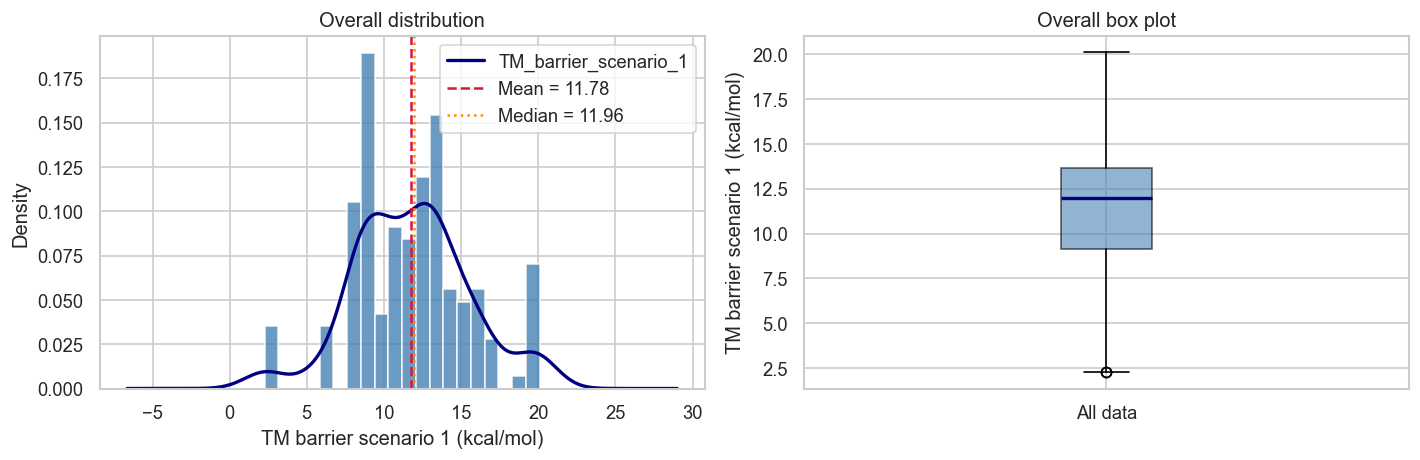

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram + KDE
axes[0].hist(df[TARGET], bins=20, color='steelblue', edgecolor='white', alpha=0.8, density=True)
df[TARGET].plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].axvline(df[TARGET].mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {df[TARGET].mean():.2f}')
axes[0].axvline(df[TARGET].median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {df[TARGET].median():.2f}')
axes[0].set_xlabel('TM barrier scenario 1 (kcal/mol)')
axes[0].set_ylabel('Density')
axes[0].set_title('Overall distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(df[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_ylabel('TM barrier scenario 1 (kcal/mol)')
axes[1].set_xticklabels(['All data'])
axes[1].set_title('Overall box plot')

plt.tight_layout()
plt.show()

## 3. Analysis by temperature

In [7]:
temp_stats = (
    df.groupby('temp_C')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
)
temp_stats

,mean,median,std,min,max,count
temp_C,,,,,,
30,11.782,11.744,3.780,2.266,20.093,32
50,11.752,11.692,3.774,2.290,20.088,32
70,11.753,11.640,3.751,2.315,20.083,32
90,11.780,11.604,3.767,2.342,20.079,32
110,11.824,12.141,3.827,2.370,20.074,32


C:\Users\livio\AppData\Local\Temp\ipykernel_12260\1080378927.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,


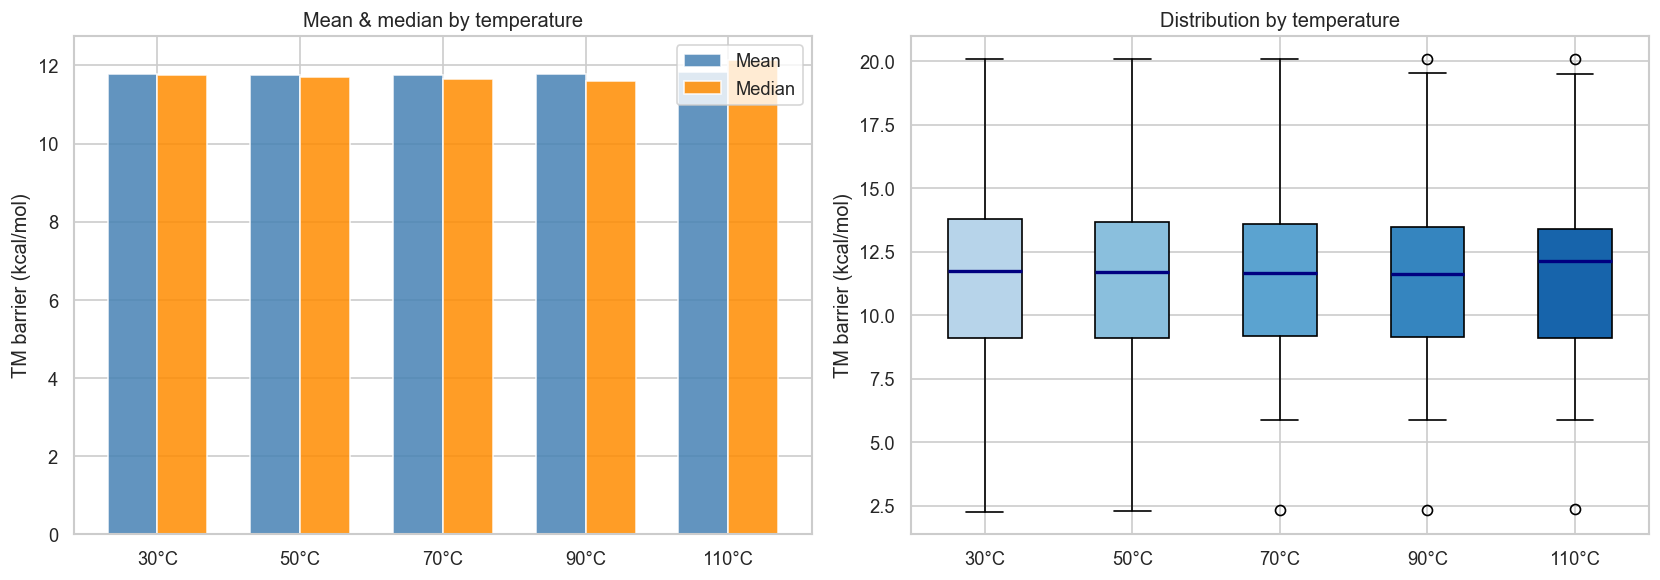

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

temps = sorted(df['temp_C'].unique())
labels = [f'{t}°C' for t in temps]
x = np.arange(len(temps))
w = 0.35

axes[0].bar(x - w/2, temp_stats['mean'],   width=w, label='Mean',   color='steelblue',  alpha=0.85)
axes[0].bar(x + w/2, temp_stats['median'], width=w, label='Median', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by temperature')
axes[0].legend()

data_by_temp = [df[df['temp_C'] == t][TARGET].values for t in temps]
bp = axes[1].boxplot(data_by_temp, labels=labels, patch_artist=True,
                     medianprops=dict(color='navy', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(temps)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by temperature')

plt.tight_layout()
plt.show()

C:\Users\livio\AppData\Local\Temp\ipykernel_12260\274765645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)


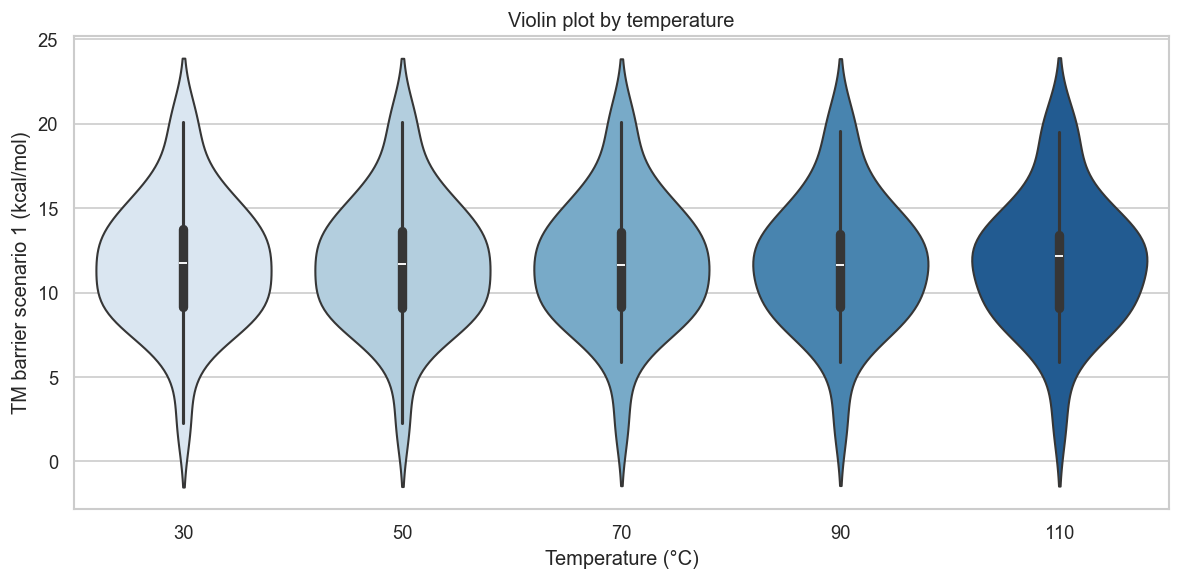

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x='temp_C', y=TARGET, palette='Blues', inner='box', ax=ax)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Violin plot by temperature')
plt.tight_layout()
plt.show()

## 4. Analysis by substrate

In [10]:
sub_stats = (
    df.groupby('substrate')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
sub_stats

,mean,median,std,min,max,count
substrate,,,,,,
2_chloropyridine,10.359,10.667,4.459,2.266,15.925,40
3_chloropyridine,12.021,12.445,2.523,8.154,18.503,80
3_bromoquinoline,12.712,12.086,4.576,7.682,20.093,40


C:\Users\livio\AppData\Local\Temp\ipykernel_12260\3114221531.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])


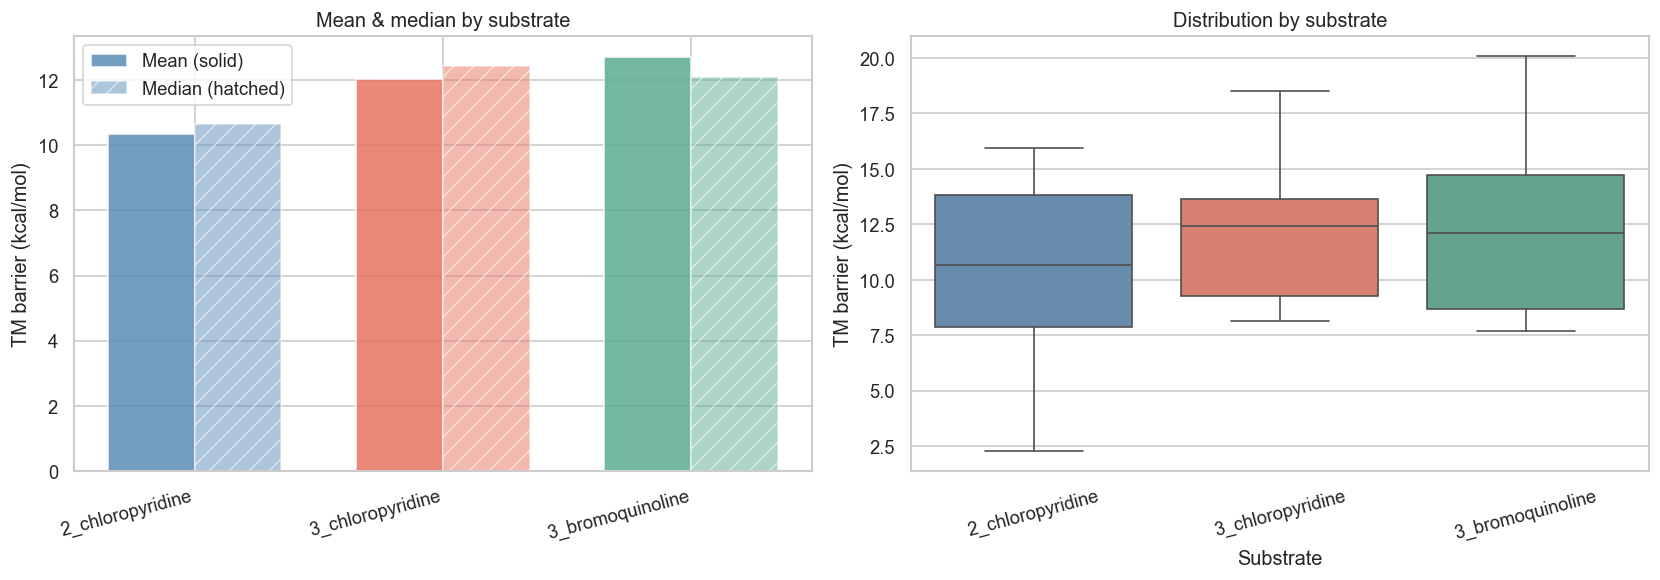

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

substrates = sub_stats.index.tolist()
x = np.arange(len(substrates))
w = 0.35
sub_colors = ['#5B8DB8', '#E87461', '#5BAD92']

axes[0].bar(x - w/2, sub_stats['mean'],   width=w, color=sub_colors, alpha=0.85, label='Mean')
axes[0].bar(x + w/2, sub_stats['median'], width=w, color=sub_colors, alpha=0.5,  hatch='//', label='Median')
axes[0].set_xticks(x)
axes[0].set_xticklabels(substrates, rotation=15, ha='right')
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by substrate')
axes[0].legend(['Mean (solid)', 'Median (hatched)'])

sns.boxplot(data=df, x='substrate', y=TARGET, palette=sub_colors, order=substrates, ax=axes[1])
axes[1].set_xlabel('Substrate')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by substrate')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

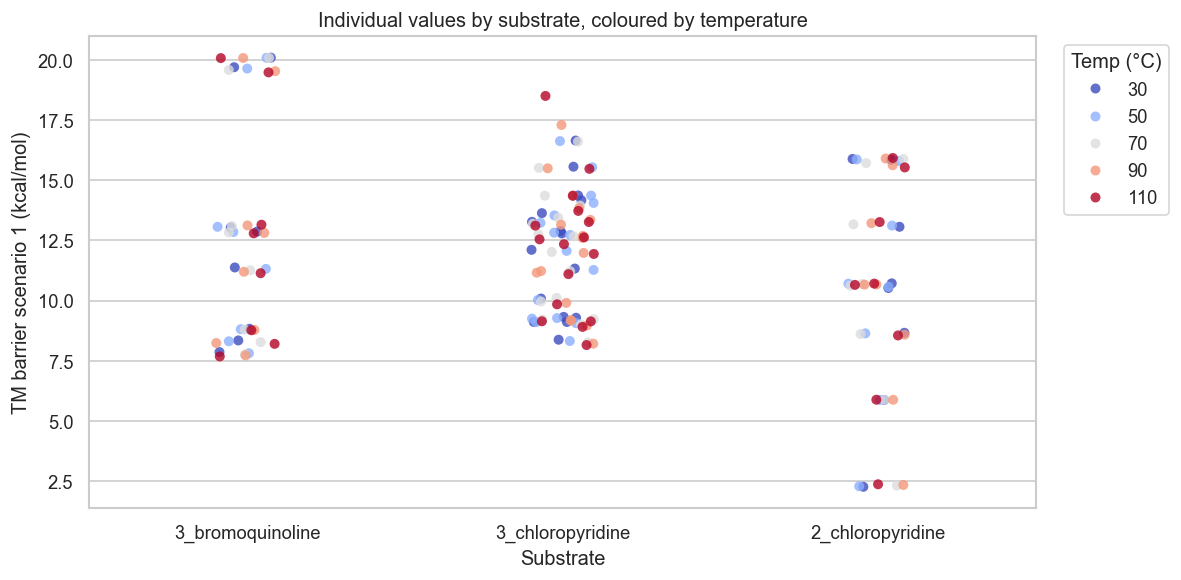

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=df, x='substrate', y=TARGET, hue='temp_C',
              palette='coolwarm', jitter=True, size=6, alpha=0.8, ax=ax)
ax.set_xlabel('Substrate')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Individual values by substrate, coloured by temperature')
ax.legend(title='Temp (°C)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Analysis by ligand

In [13]:
lig_stats = (
    df.groupby('ligand')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
lig_stats

,mean,median,std,min,max,count
ligand,,,,,,
AmPhos,9.162,8.985,2.506,5.872,12.890,20
PPh3,9.206,8.900,1.306,7.682,11.332,20
tBu3,9.576,11.440,4.488,2.266,13.273,20
Catacxium_A,9.974,9.514,1.891,8.154,12.791,20
XPhos,13.166,11.985,4.139,8.909,19.696,20
PCy3,13.235,12.918,1.782,11.139,15.885,20
SPhos,13.445,13.121,2.582,9.108,18.503,20
RuPhos,16.462,15.706,2.222,14.357,20.093,20


C:\Users\livio\AppData\Local\Temp\ipykernel_12260\3524323678.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,


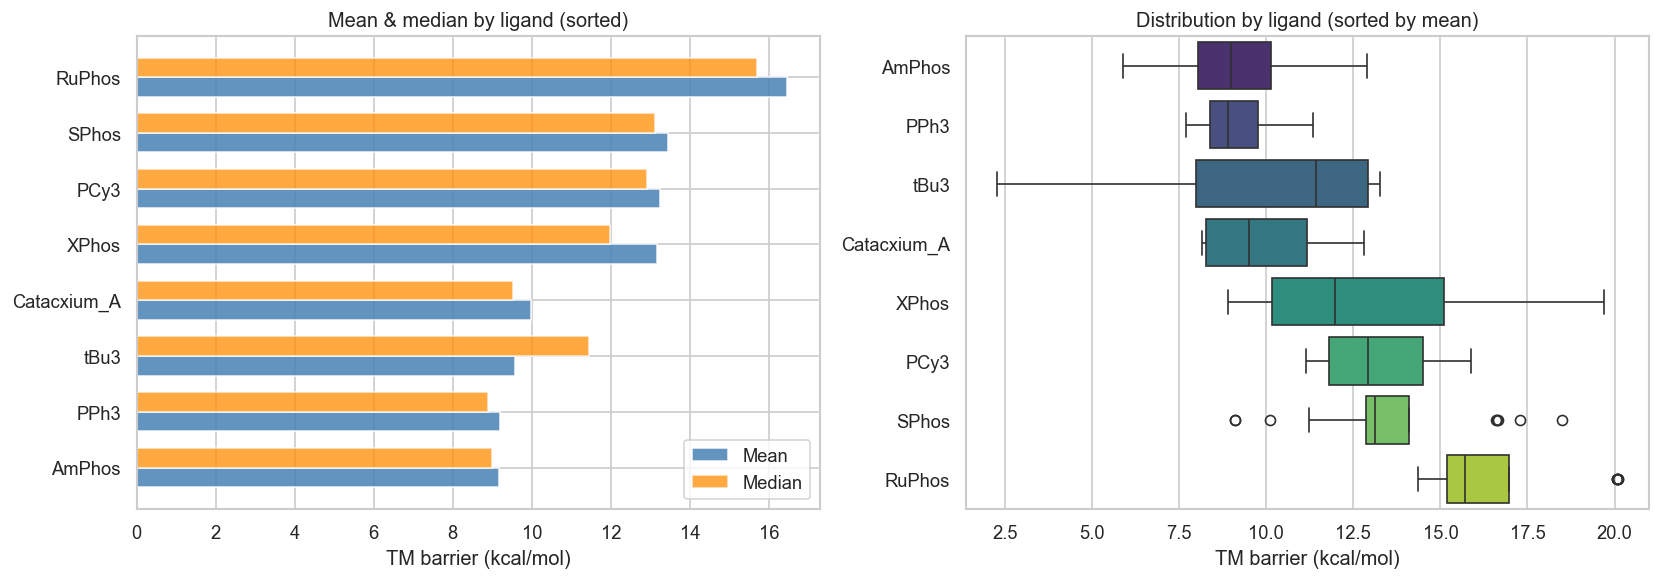

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ligands = lig_stats.index.tolist()
y = np.arange(len(ligands))
w = 0.35

axes[0].barh(y - w/2, lig_stats['mean'],   height=w, label='Mean',   color='steelblue',  alpha=0.85)
axes[0].barh(y + w/2, lig_stats['median'], height=w, label='Median', color='darkorange', alpha=0.75)
axes[0].set_yticks(y)
axes[0].set_yticklabels(ligands)
axes[0].set_xlabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by ligand (sorted)')
axes[0].legend()

sns.boxplot(data=df, y='ligand', x=TARGET, order=ligands,
            palette='viridis', orient='h', ax=axes[1])
axes[1].set_xlabel('TM barrier (kcal/mol)')
axes[1].set_ylabel('')
axes[1].set_title('Distribution by ligand (sorted by mean)')

plt.tight_layout()
plt.show()

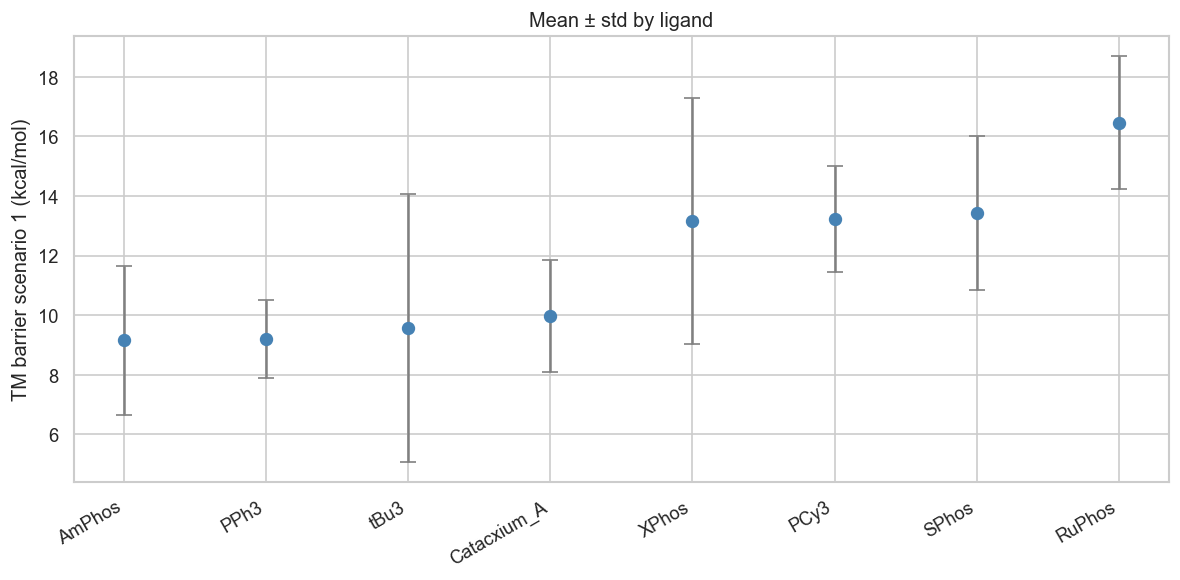

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    x=range(len(ligands)),
    y=lig_stats['mean'],
    yerr=lig_stats['std'],
    fmt='o', color='steelblue', ecolor='gray',
    elinewidth=1.5, capsize=5, markersize=7
)
ax.set_xticks(range(len(ligands)))
ax.set_xticklabels(ligands, rotation=30, ha='right')
ax.set_ylabel('TM barrier scenario 1 (kcal/mol)')
ax.set_title('Mean ± std by ligand')
plt.tight_layout()
plt.show()

## 6. Analysis by case

In [16]:
case_stats = (
    df.groupby('case')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
case_stats

,mean,median,std,min,max,count
case,,,,,,
case4,10.359,10.667,4.459,2.266,15.925,40
case2,11.151,9.584,2.979,8.154,18.503,40
case1,12.712,12.086,4.576,7.682,20.093,40
case3,12.891,13.002,1.570,9.108,15.563,40


C:\Users\livio\AppData\Local\Temp\ipykernel_12260\219987495.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='case', y=TARGET, palette=case_colors, order=cases, ax=axes[1])


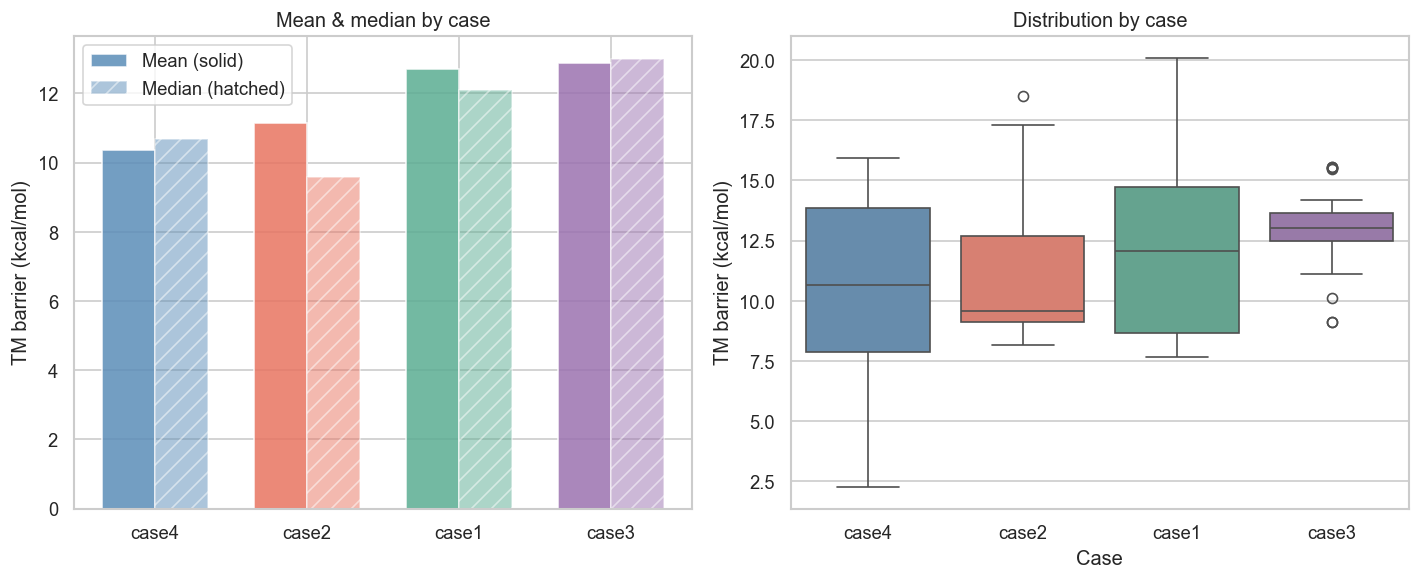

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cases = case_stats.index.tolist()
case_colors = ['#5B8DB8', '#E87461', '#5BAD92', '#9B72B0']

x = np.arange(len(cases))
w = 0.35
axes[0].bar(x - w/2, case_stats['mean'],   width=w, color=case_colors, alpha=0.85, label='Mean')
axes[0].bar(x + w/2, case_stats['median'], width=w, color=case_colors, alpha=0.5,  hatch='//', label='Median')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cases)
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Mean & median by case')
axes[0].legend(['Mean (solid)', 'Median (hatched)'])

sns.boxplot(data=df, x='case', y=TARGET, palette=case_colors, order=cases, ax=axes[1])
axes[1].set_xlabel('Case')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by case')

plt.tight_layout()
plt.show()

## 7. Analysis by boron species

In [18]:
boh2_stats = (
    df.groupby('BOH2_short')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
print('BOH2 species:')
display(boh2_stats)

bpin_stats = (
    df.groupby('BPin_short')[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .round(3)
    .sort_values('mean')
)
print('BPin species:')
display(bpin_stats)

BOH2 species:


,mean,median,std,min,max,count
BOH2_short,,,,,,
BOH2-cpd9,10.359,10.667,4.459,2.266,15.925,40
BOH2-cpd2,11.931,10.612,3.916,7.682,20.093,80
BOH2-cpd6,12.891,13.002,1.570,9.108,15.563,40


BPin species:


,mean,median,std,min,max,count
BPin_short,,,,,,
BPin-cpd9,10.359,10.667,4.459,2.266,15.925,40
BPin-cpd2,11.931,10.612,3.916,7.682,20.093,80
BPin-cpd6,12.891,13.002,1.570,9.108,15.563,40


C:\Users\livio\AppData\Local\Temp\ipykernel_12260\3939648863.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='BOH2_short', y=TARGET, palette=boron_colors,
C:\Users\livio\AppData\Local\Temp\ipykernel_12260\3939648863.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='BPin_short', y=TARGET, palette=boron_colors,


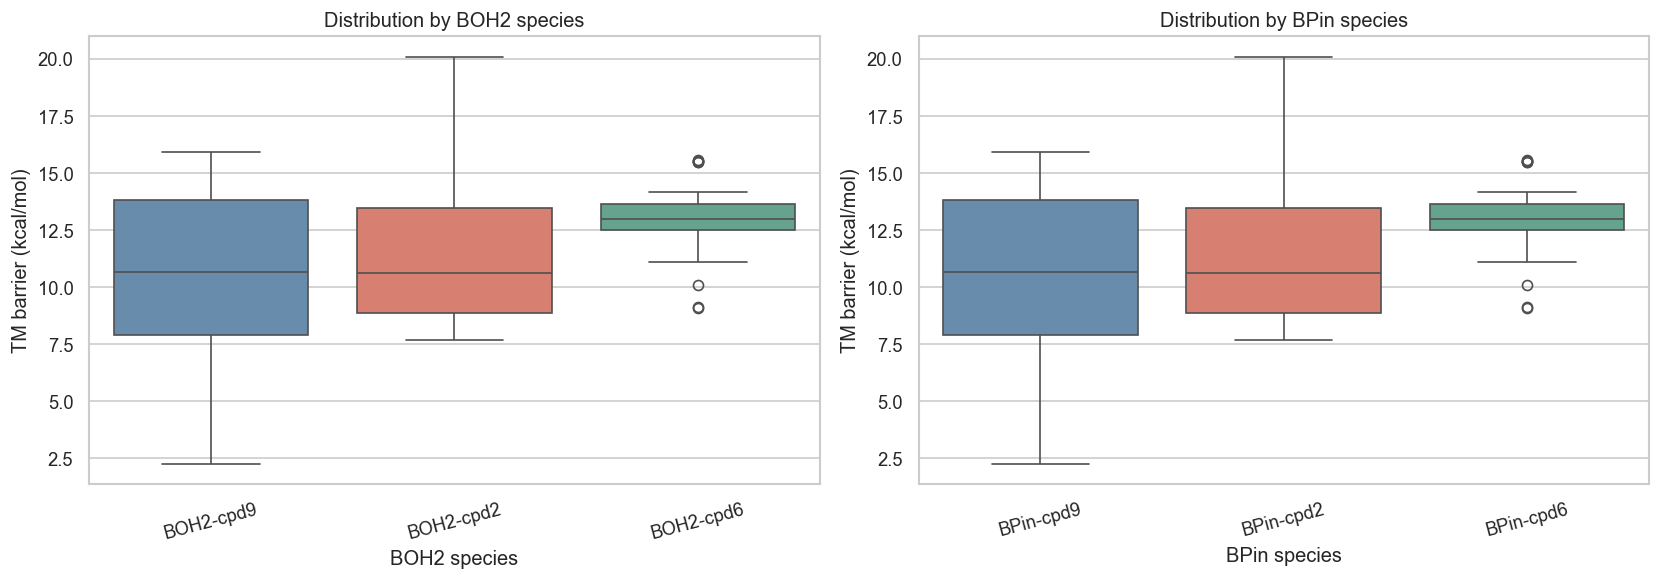

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
boron_colors = ['#5B8DB8', '#E87461', '#5BAD92']

sns.boxplot(data=df, x='BOH2_short', y=TARGET, palette=boron_colors,
            order=boh2_stats.index.tolist(), ax=axes[0])
axes[0].set_xlabel('BOH2 species')
axes[0].set_ylabel('TM barrier (kcal/mol)')
axes[0].set_title('Distribution by BOH2 species')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='BPin_short', y=TARGET, palette=boron_colors,
            order=bpin_stats.index.tolist(), ax=axes[1])
axes[1].set_xlabel('BPin species')
axes[1].set_ylabel('TM barrier (kcal/mol)')
axes[1].set_title('Distribution by BPin species')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Heatmap: ligand × substrate (mean TM barrier)

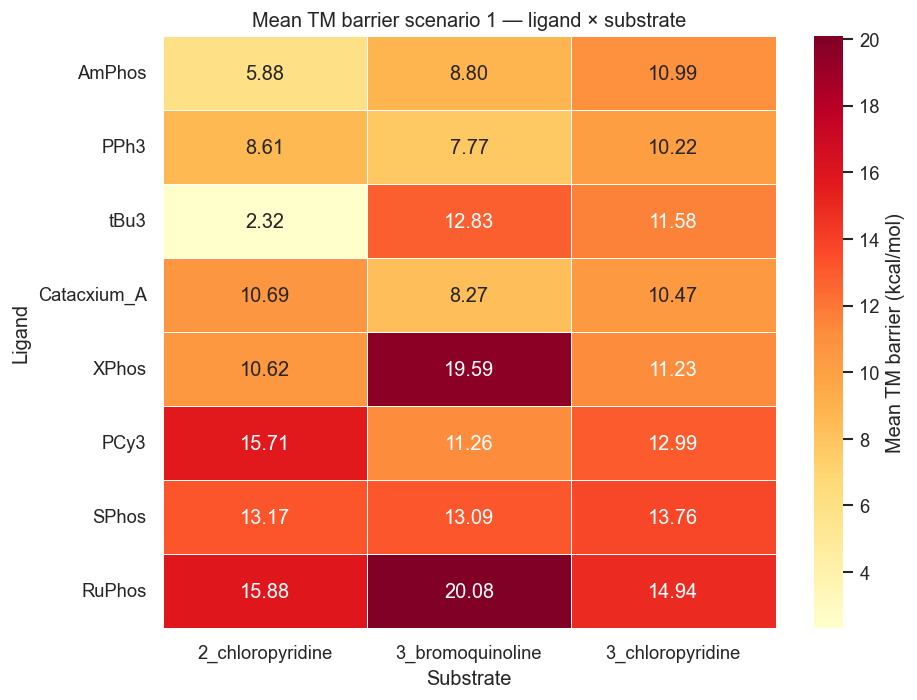

In [20]:
pivot_sub = df.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')
pivot_sub = pivot_sub.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × substrate')
ax.set_xlabel('Substrate')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

### 30°C specifically

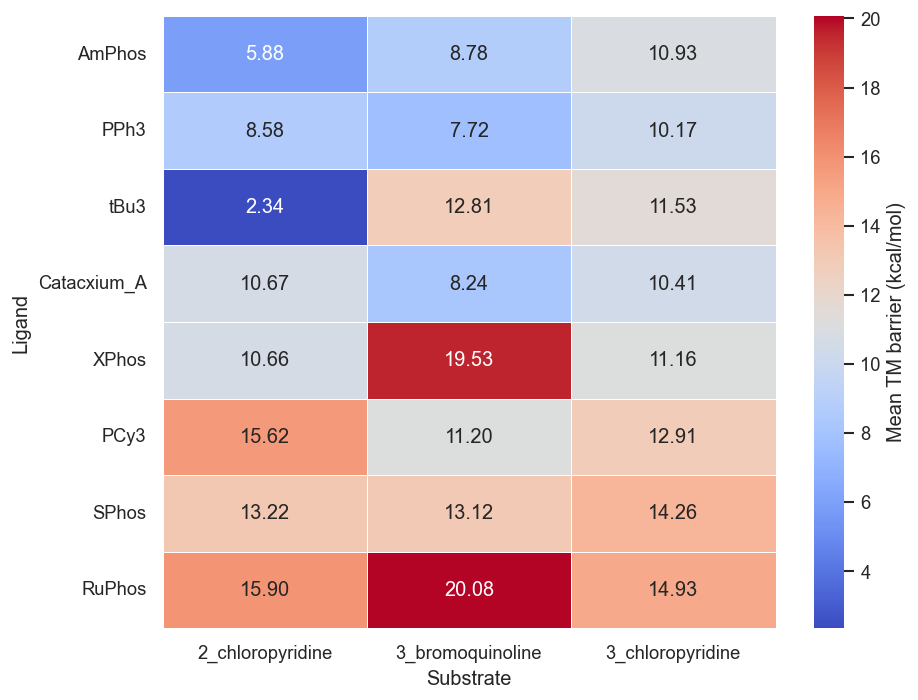

In [28]:
df_30 = df[df['temp_C'] == 90]
pivot_sub = df_30.pivot_table(values=TARGET, index='ligand', columns='substrate', aggfunc='mean')
pivot_sub=  pivot_sub.loc[pivot_sub.mean(axis=1).sort_values().index]
pivot_sub = pivot_sub.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 - 30°C — ligand × substrate')
ax.set_xlabel('Substrate')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 9. Heatmap: ligand × temperature (mean TM barrier)

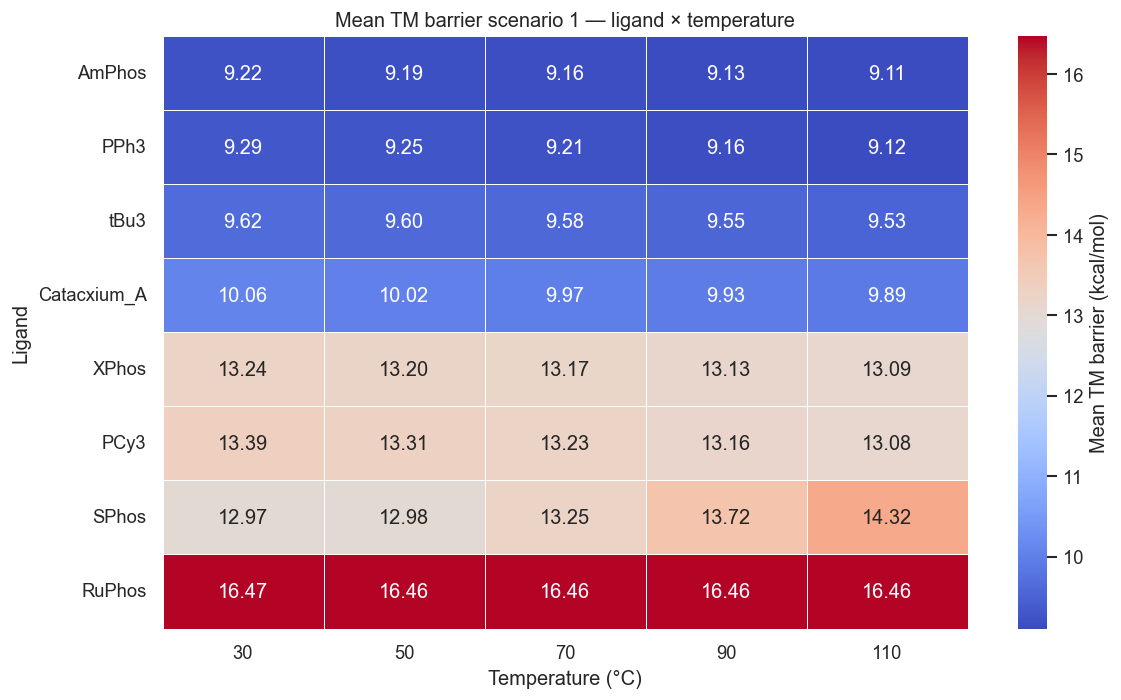

In [23]:
pivot_temp = df.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')
pivot_temp = pivot_temp.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × temperature')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

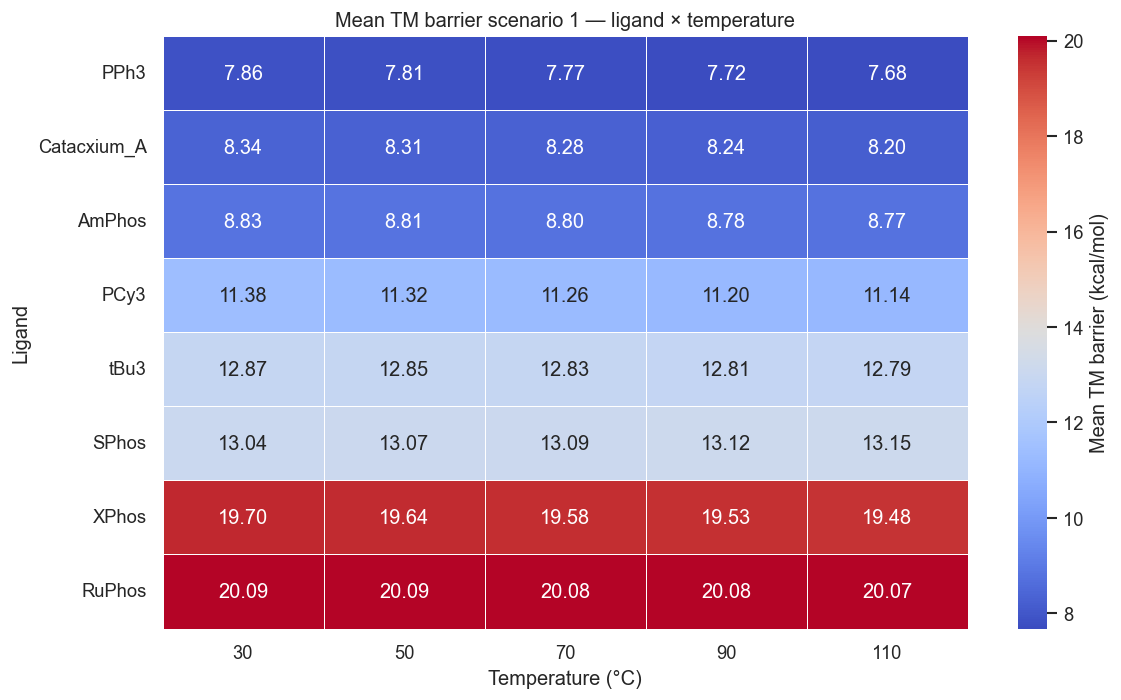

In [49]:
df_case4 = df[df['case'] == 'case1']

pivot_temp = df_case4.pivot_table(values=TARGET, index='ligand', columns='temp_C', aggfunc='mean')
pivot_temp=  pivot_temp.loc[pivot_temp.mean(axis=1).sort_values().index]
# pivot_temp = pivot_temp.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_temp, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × temperature')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 10. Heatmap: ligand × case (mean TM barrier)

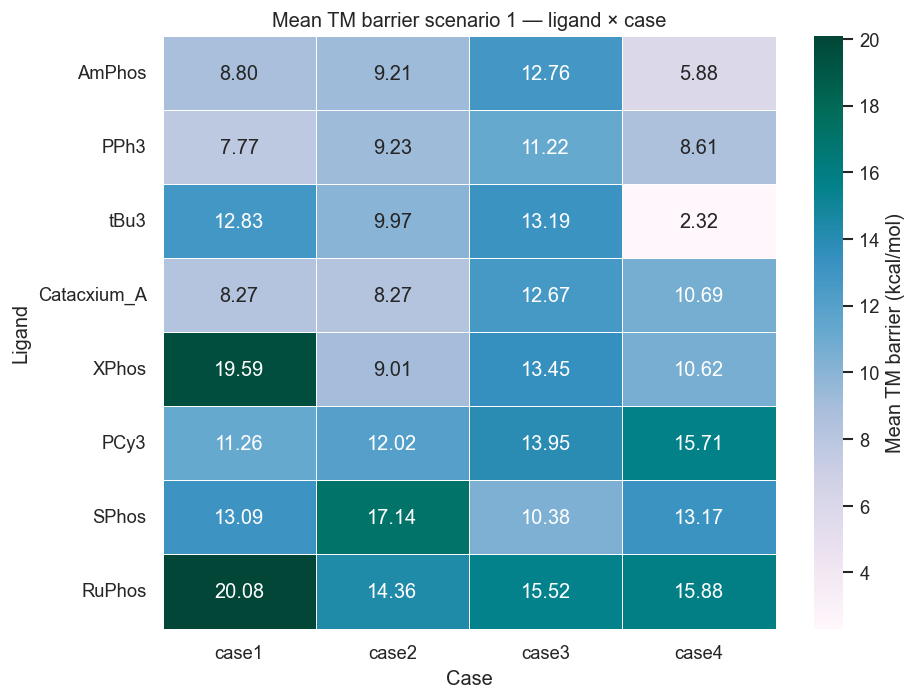

In [46]:
pivot_case = df.pivot_table(values=TARGET, index='ligand', columns='case', aggfunc='mean')
pivot_case=  pivot_case.loc[pivot_case.mean(axis=1).sort_values().index]
# pivot_case = pivot_case.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_case, annot=True, fmt='.2f', cmap='PuBuGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
ax.set_title('Mean TM barrier scenario 1 — ligand × case')
ax.set_xlabel('Case')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

#### 30°C specifically

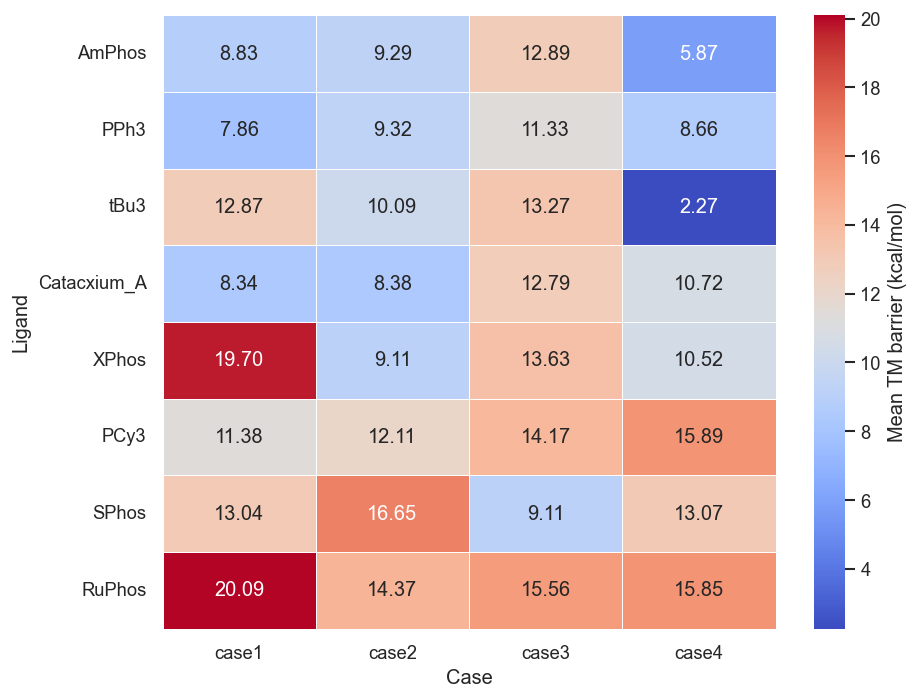

In [36]:
df_30_TM = df[df['temp_C'] == 30]
pivot_sub = df_30_TM.pivot_table(values=TARGET, index='ligand', columns='case', aggfunc='mean')
pivot_sub = pivot_sub.loc[lig_stats.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_sub, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean TM barrier (kcal/mol)'})
# ax.set_title('Mean TM barrier scenario 1 - 30°C — ligand × substrate')
ax.set_xlabel('Case')
ax.set_ylabel('Ligand')
plt.tight_layout()
plt.show()

## 11. Interaction: barrier vs temperature, per ligand

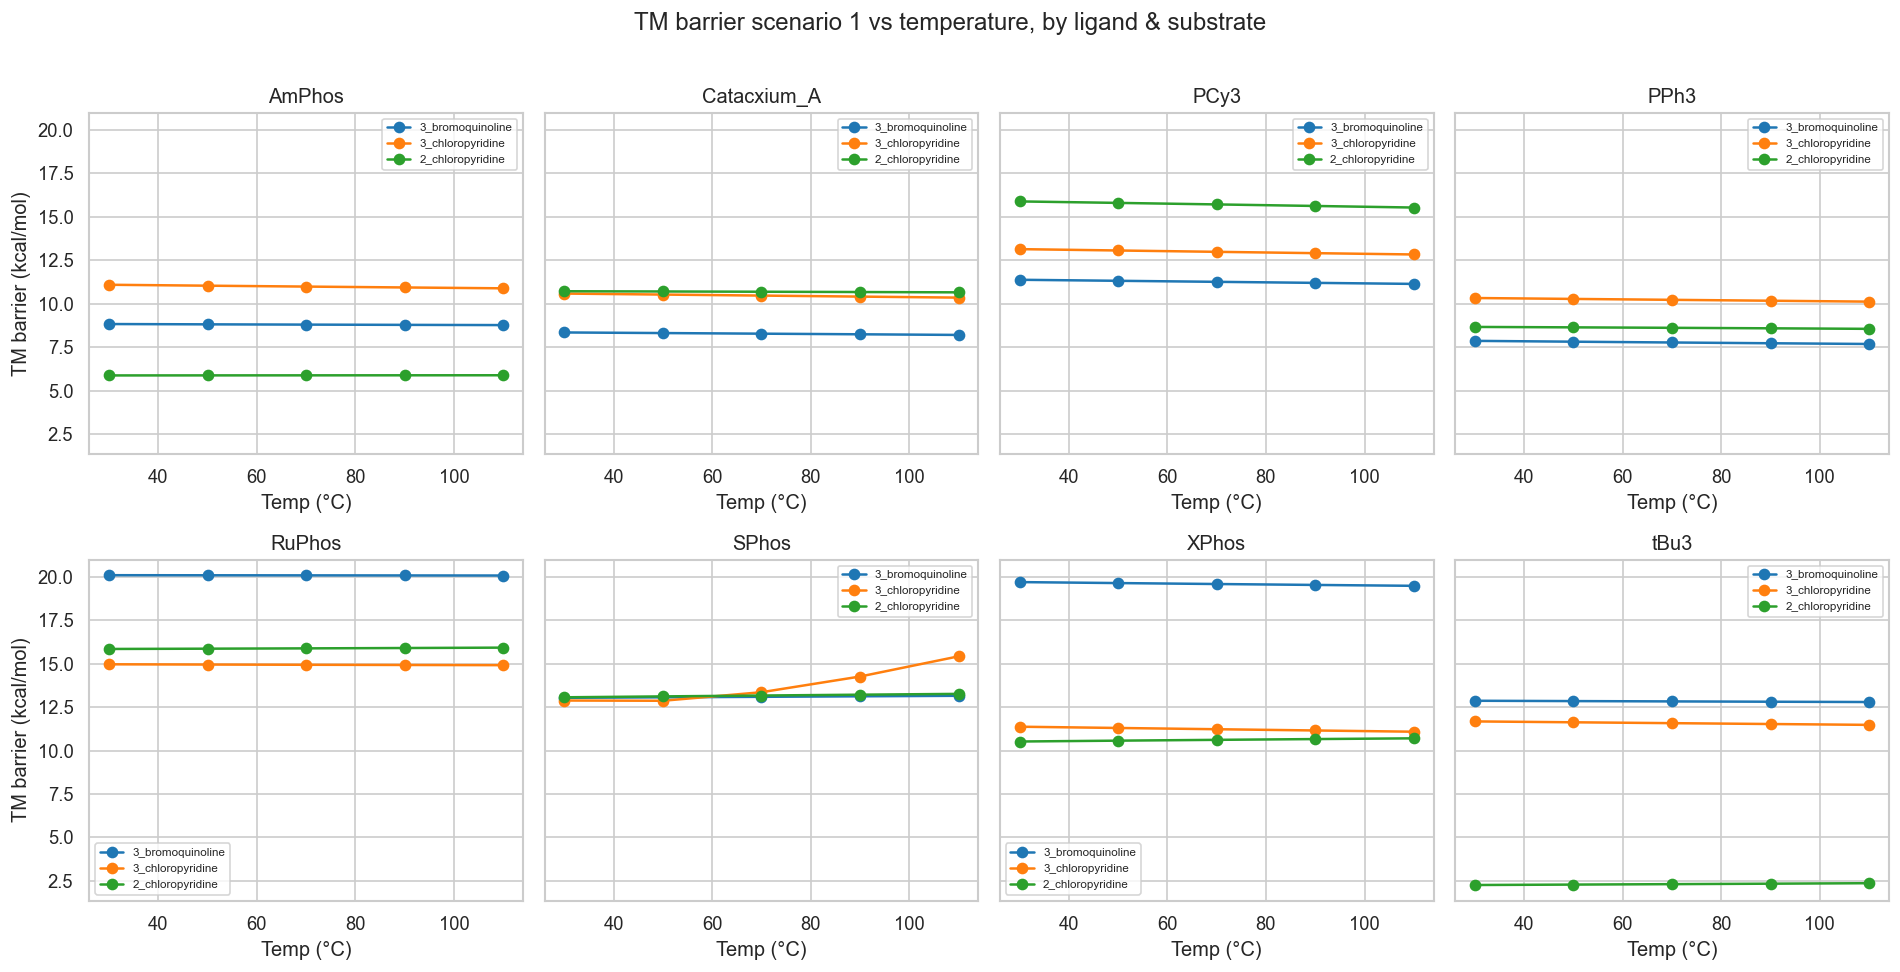

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', len(df['substrate'].unique()))

for i, lig in enumerate(sorted(df['ligand'].unique())):
    sub_df = df[df['ligand'] == lig]
    for j, sub in enumerate(df['substrate'].unique()):
        s = sub_df[sub_df['substrate'] == sub].groupby('temp_C')[TARGET].mean().reset_index()
        axes[i].plot(s['temp_C'], s[TARGET], marker='o', label=sub, color=palette[j])
    axes[i].set_title(lig)
    axes[i].set_xlabel('Temp (°C)')
    if i % 4 == 0:
        axes[i].set_ylabel('TM barrier (kcal/mol)')
    axes[i].legend(fontsize=7)

plt.suptitle('TM barrier scenario 1 vs temperature, by ligand & substrate', y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary statistics table

In [ ]:
summary = (
    df.groupby(['ligand', 'substrate', 'temp_C', 'case'])[TARGET]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
    .reset_index()
)
summary.head(20)